<a href="https://colab.research.google.com/github/SlepenkovaDaria/My-homework/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as hc
from sklearn.cluster import AgglomerativeClustering
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import seaborn as sns
from collections import Counter
from itertools import combinations

In [ ]:
drive.mount("/content/drive")
products_only = pd.read_csv("/content/drive/MyDrive/products_only.csv")
customer_features_scaled = pd.read_csv("/content/drive/MyDrive/customer_features_scaled.csv")
customer_features_first = pd.read_csv("/content/drive/MyDrive/customer_features_first.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Кластеризация

In [ ]:
customer_features_scaled.head()

,Customer ID,Recency_log,Frequency_log,Monetary_log,Returned,Returned_int
0,12347,0.261464,0.890943,1.293361,True,1
1,12348,1.007901,0.239268,-1.395174,False,0
2,12350,1.218109,-0.874777,-0.411345,False,0
3,12352,-1.063888,1.138698,0.682549,True,1
4,12353,0.803541,-0.874777,-1.406261,False,0


In [ ]:
customer_features_scaled.shape

(3607, 6)

In [ ]:
customer_features_scaled.describe().round(5)

,Customer ID,Recency_log,Frequency_log,Monetary_log,Returned_int
count,3607.00000,3607.00000,3607.00000,3607.00000,3607.00000
mean,15264.84696,0.00000,-0.00000,0.00000,0.48240
std,1719.03659,1.00014,1.00014,1.00014,0.49976
min,12347.00000,-2.93132,-0.87478,-4.03379,0.00000
25%,13763.50000,-0.71855,-0.87478,-0.65254,0.00000
50%,15239.00000,0.17026,-0.22310,-0.04160,0.00000
75%,16741.00000,0.84417,0.59791,0.68361,1.00000
max,18287.00000,1.38940,5.97632,4.09214,1.00000


In [ ]:
X = customer_features_scaled.iloc[:, 1:4]
X.head()

,Recency_log,Frequency_log,Monetary_log
0,0.261464,0.890943,1.293361
1,1.007901,0.239268,-1.395174
2,1.218109,-0.874777,-0.411345
3,-1.063888,1.138698,0.682549
4,0.803541,-0.874777,-1.406261


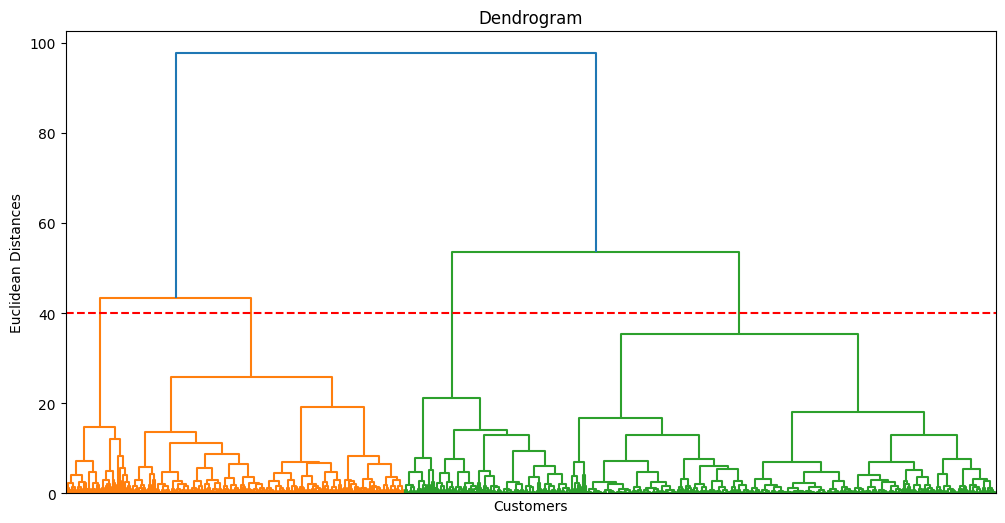

In [ ]:
plt.figure(figsize = (12, 6))
dendogram  = hc.dendrogram(hc.linkage(X, method = "ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distances")
plt.xticks([])
plt.axhline(40, c = "r", linestyle = "--")
plt.show()

In [ ]:
model = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
y_clusters = model.fit_predict(X) + 1

X_with_clusters = X.copy()
X_with_clusters["cluster"] = y_clusters

cluster_summary = X_with_clusters.groupby("cluster").agg({
    "Recency_log": "mean",
    "Frequency_log": "mean",
    "Monetary_log": "mean"})

cluster_summary["Count"] = X_with_clusters["cluster"].value_counts().sort_index()
print(cluster_summary)

         Recency_log  Frequency_log  Monetary_log  Count
cluster                                                 
1           0.816090      -0.617418     -0.627628   1645
2          -0.375948       0.709297      0.768236   1055
3          -0.915062      -0.512981     -0.358567    648
4          -1.362481       2.315657      1.754098    259


Проанализируем каждый кластер:

1. Высокий Recency_log, низкий Frequency_log, низкий Monetary_log:
эти клиенты давно не совершали покупок, редко и мало покупали. **Назовем этот кластер Inactive.**

2. Низкий Recency_log, средний Frequency_log, средний Monetary_log:
эти клиенты возвращались совсем недавно, посещали магазин и тратили средства умеренно. **Назовем этот кластер Loyal.**

3. Низкий Recency_log, низкий Frequency_log, низкий Monetary_log:
эти клиенты возвращались совсем недавно, но посещали магазин и тратили средства совсем немного. **Назовем этот кластер New.**

4. Низкий Recency_log, высокий Frequency_log, высокий Monetary_log:
эти клиенты совершали покупки совсем недавно, при этом посещали магазин достаточно часто и тратили большое количество денег. **Назовем этот кластер VIP.**

In [ ]:
cluster_names = {
    1: "Inactive",
    2: "Loyal",
    3: "New",
    4: "VIP"}

X_with_clusters["segment"] = X_with_clusters["cluster"].map(cluster_names)

fig = px.scatter_3d(
    X_with_clusters,
    x = "Recency_log",
    y = "Frequency_log",
    z = "Monetary_log",
    color = "segment",
    title = "Customer Segments",
    width = 1000,
    height = 800)

fig.show()

# Регрессия

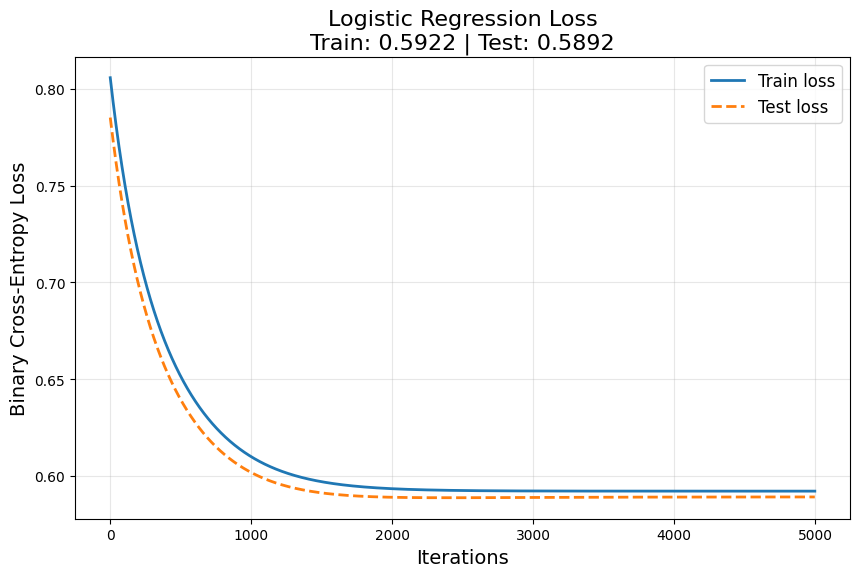

Train metrics
              precision    recall  f1-score   support

           0       0.68      0.78      0.73      1131
           1       0.71      0.60      0.65      1033

    accuracy                           0.69      2164
   macro avg       0.69      0.69      0.69      2164
weighted avg       0.69      0.69      0.69      2164

Test metrics
              precision    recall  f1-score   support

           0       0.68      0.74      0.71       736
           1       0.70      0.63      0.66       707

    accuracy                           0.69      1443
   macro avg       0.69      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443

Train accuracy: 0.6917744916820703
Test accuracy: 0.6860706860706861


In [ ]:
X = customer_features_scaled[["Recency_log", "Frequency_log", "Monetary_log"]].values
y = customer_features_scaled["Returned_int"].values

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def grad_step(w, X, y):
    return X.T @ (sigmoid(X @ w) - y) / len(y)

def bce_loss(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

X = np.hstack([X, np.ones((len(X), 1))])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.4,
    random_state = 42)

w = np.ones(X.shape[1])
rate = 0.01
n_iters = 5000

loss_train = []
loss_test = []

for i in range(n_iters):
    w = w - rate * grad_step(w, X_train, y_train)

    y_train_pred = sigmoid(X_train @ w)
    y_test_pred = sigmoid(X_test @ w)

    loss_train.append(bce_loss(y_train, y_train_pred))
    loss_test.append(bce_loss(y_test, y_test_pred))

plt.figure(figsize = (10, 6))
plt.plot(loss_train, label = "Train loss", lw = 2)
plt.plot(loss_test, label = "Test loss", lw = 2, linestyle = "--")
plt.xlabel("Iterations", fontsize = 14)
plt.ylabel("Binary Cross-Entropy Loss", fontsize = 14)
plt.title(
    f"Logistic Regression Loss\n"
    f"Train: {loss_train[-1]:.4f} | Test: {loss_test[-1]:.4f}",
    fontsize = 16
)
plt.legend(fontsize = 12)
plt.grid(alpha = 0.3)
plt.show()

y_pred_train = (sigmoid(X_train @ w) > 0.5).astype(int)
y_pred_test = (sigmoid(X_test @ w) > 0.5).astype(int)

print("Train metrics")
print(classification_report(y_train, y_pred_train))

print("Test metrics")
print(classification_report(y_test, y_pred_test))

print(f"Train accuracy: {accuracy_score(y_train, y_pred_train)}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_test)}")

Происходит снижение значения loss, то есть модель действительно обучается, однако примерно после 2000 итераций значение loss почти перестает меняться. Признаков переобучения тоже нет. Модель стала лучше случайного угадывания, но качество предсказаний все равно далеко от идеального.

Модель правильно классифицирует примерно 69% клиентов. Разницы между train и test почти нет. У класса 0 f1-score =  0.71, а у класса 1 - 0.66, то есть модель лучше справляется с классом 0, чем с классом 1.

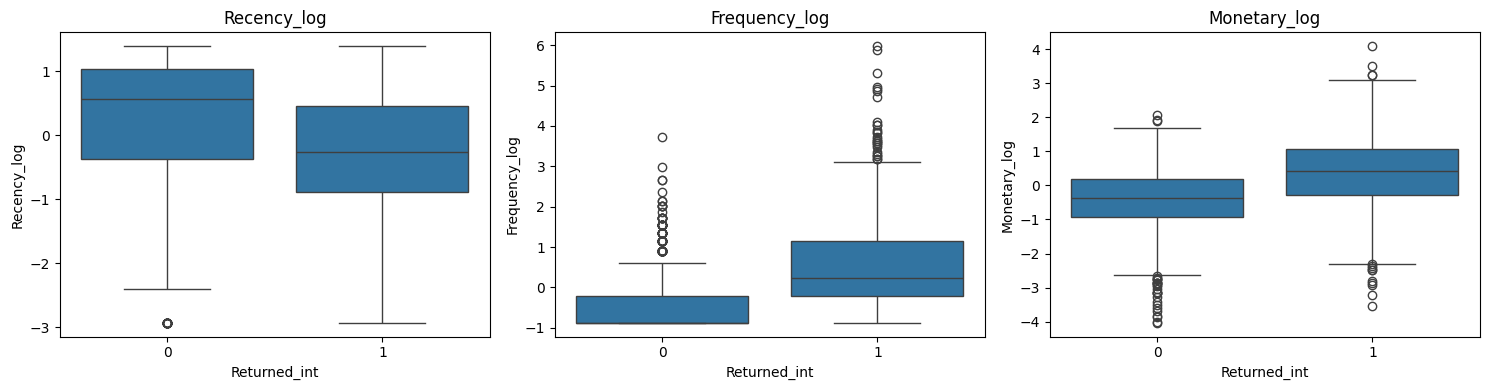

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

for ax, col in zip(axes, ["Recency_log", "Frequency_log", "Monetary_log"]):
    sns.boxplot(
        data = customer_features_scaled,
        x = "Returned_int",
        y = col,
        ax = ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Распределения признаков для двух классов существенно перекрываются. Несмотря на различие медиан, диапазоны значений и межквартильные интервалы для Returned_int = 0 и Returned_int = 1 во многом совпадают. Следовательно, ни один из признаков сам по себе не позволяет чётко разделить классы. Наиболее информативным признаком выглядит Frequency_log, поскольку различие между классами для него наиболее заметно.

Модели необходимы новые признаки, например:
1. avg_order_value - средняя сумма одного заказа клиента
2. avg_items_order - среднее количество товаров в одном заказе и др.

# Исследование товаров магазина и временной анализ

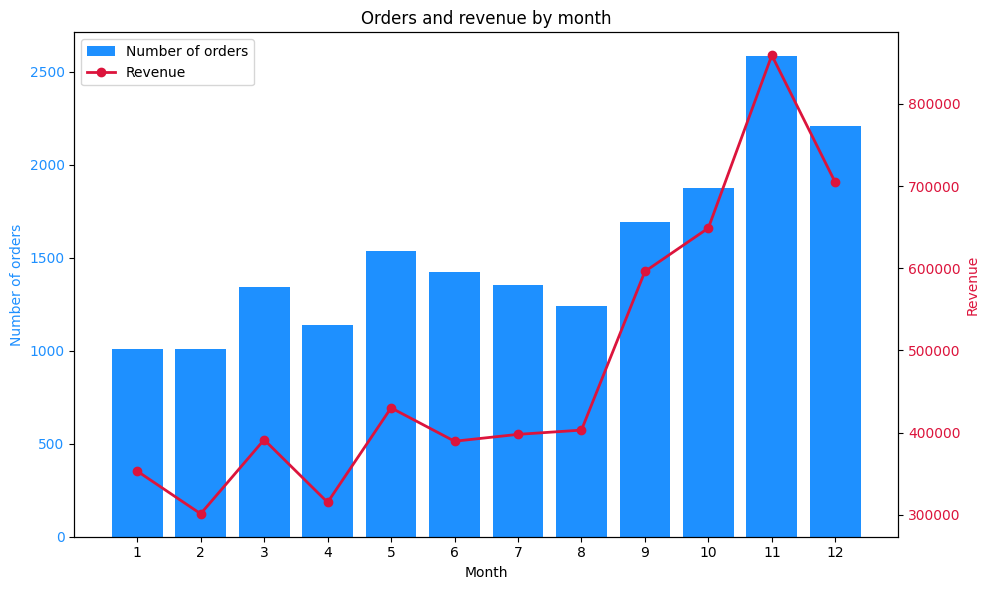

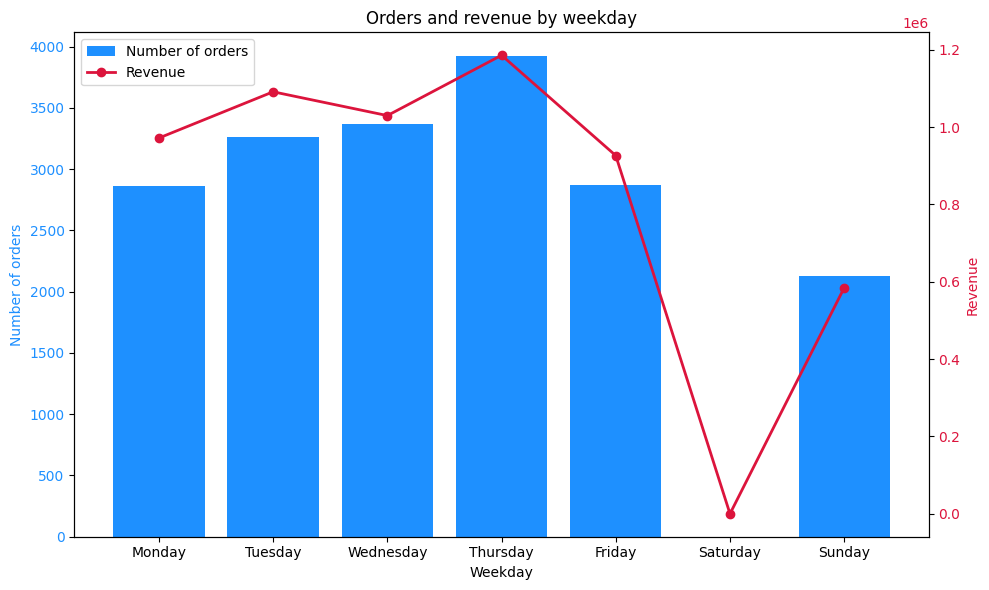

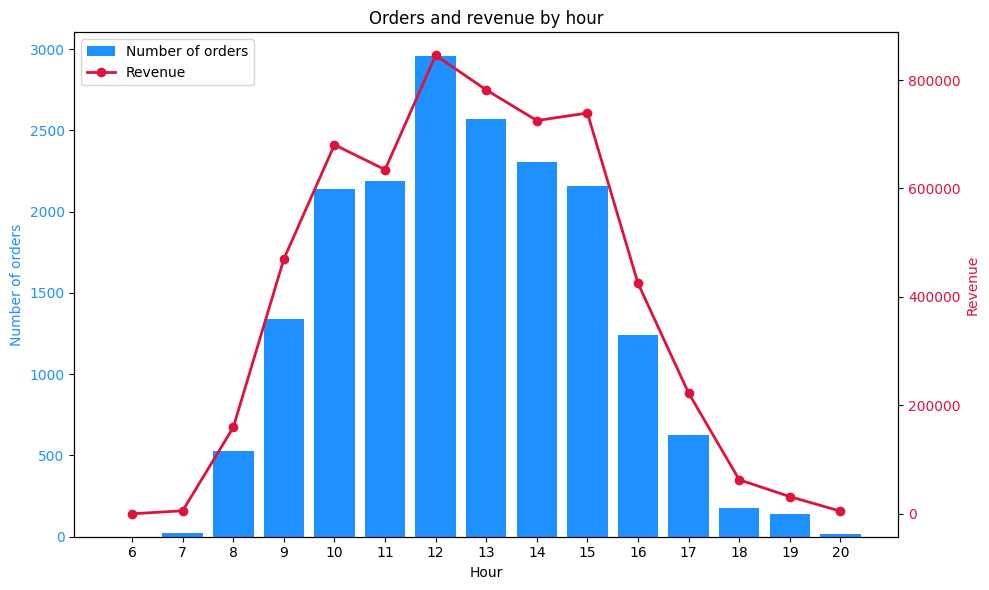

In [ ]:
products_only["InvoiceDate"] = pd.to_datetime(
    products_only["InvoiceDate"],
    format = "%Y-%m-%d %H:%M:%S",
    errors = "coerce")

products_only["Year"] = products_only["InvoiceDate"].dt.year
products_only["Month"] = products_only["InvoiceDate"].dt.month
products_only["MonthName"] = products_only["InvoiceDate"].dt.month_name()
products_only["Weekday"] = products_only["InvoiceDate"].dt.day_name()
products_only["Hour"] = products_only["InvoiceDate"].dt.hour

monthly = (products_only.groupby("Month")
          .agg(Orders = ("Invoice", "nunique"), Revenue = ("Revenue", "sum"))
          .reset_index())

fig, ax1 = plt.subplots(figsize = (10, 6))

ax1.bar(monthly["Month"], monthly["Orders"], color = "dodgerblue", label = "Number of orders")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of orders", color = "dodgerblue")
ax1.tick_params(axis = "y", labelcolor = "dodgerblue")

ax2 = ax1.twinx()

ax2.plot(monthly["Month"], monthly["Revenue"], color = "crimson", marker = "o",
                linewidth = 2, label = "Revenue")
ax2.set_ylabel("Revenue", color = "crimson")
ax2.tick_params(axis = "y", labelcolor = "crimson")

plt.title("Orders and revenue by month")
plt.xticks(monthly["Month"])

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc = "upper left")

plt.tight_layout()
plt.show()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday = (products_only.groupby("Weekday")
          .agg(Orders = ("Invoice", "nunique"), Revenue = ("Revenue", "sum"))
          .reindex(weekday_order)
          .fillna(0)
          .reset_index())

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(weekday["Weekday"], weekday["Orders"], color = "dodgerblue", label = "Number of orders")
ax1.set_xlabel("Weekday")
ax1.set_ylabel("Number of orders", color = "dodgerblue")
ax1.tick_params(axis = "y", labelcolor = "dodgerblue")

ax2 = ax1.twinx()

ax2.plot(weekday["Weekday"], weekday["Revenue"], color = "crimson", marker = "o",
        linewidth = 2, label = "Revenue")
ax2.set_ylabel("Revenue", color = "crimson")
ax2.tick_params(axis = "y", labelcolor = "crimson")

plt.title("Orders and revenue by weekday")
plt.xticks(weekday["Weekday"])
plt.xticks(rotation = 45)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc = "upper left")

plt.tight_layout()
plt.show()

hourly = (products_only.groupby("Hour")
         .agg(Orders = ("Invoice", "nunique"), Revenue = ("Revenue", "sum"))
         .reset_index())

fig, ax1 = plt.subplots(figsize = (10, 6))

ax1.bar(hourly["Hour"], hourly["Orders"], color = "dodgerblue", label = "Number of orders")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Number of orders", color = "dodgerblue")
ax1.tick_params(axis = "y", labelcolor = "dodgerblue")

ax2 = ax1.twinx()

ax2.plot(hourly["Hour"], hourly["Revenue"], color = "crimson", marker = "o",
        linewidth = 2, label = "Revenue")
ax2.set_ylabel("Revenue", color = "crimson")
ax2.tick_params(axis = "y", labelcolor = "crimson")

plt.title("Orders and revenue by hour")
plt.xticks(hourly["Hour"])

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc = "upper left")

plt.tight_layout()
plt.show()

Выводы:

Продажи имеют выраженную сезонность по месяцам. После августа число заказов и выручка начинают быстро расти, а максимум приходится на ноябрь. В декабре продажи немного снижаются, но остаются очень высокими. Вероятно, это связано с предрождественским сезоном и новогодними покупками, черной пятницей.

Самые активные дни недели - вторник–четверг, особенно четверг. В эти дни и число заказов, и выручка максимальны. В пятницу активность начинает снижаться, а в воскресенье заказов заметно меньше. Суббота отсутствует в данных - вероятно, это выходной для магазина.

Большинство покупок совершается днем. Основная активность приходится примерно на 10:00 - 15:00, а пик заказов наблюдается около 12:00. После 16:00 продажи быстро снижаются, а вечером почти отсутствуют. Это похоже на поведение рабочего или корпоративного магазина, где заказы оформляют в течение рабочего дня. Выручка достигает максимума около 10:00 - 12:00 и 15:00, то есть самые прибыльные заказы тоже совершаются в середине дня.

In [ ]:
print(f"Unique products by Description: {products_only["Description"].nunique()}")
print(f"Unique products by StockCode: {products_only["StockCode"].nunique()}")

desc_per_code = (
    products_only.groupby("StockCode")["Description"]
    .nunique()
    .sort_values(ascending = False))

print(desc_per_code[desc_per_code > 1].head(20))

code = desc_per_code[desc_per_code > 1].index[0]

Unique products by Description: 3877
Unique products by StockCode: 3771
StockCode
23236     4
23196     4
23366     3
23370     3
17107D    3
22937     3
23396     3
23535     3
23240     3
23413     3
23209     3
23203     3
23244     3
22776     3
23126     3
22268     2
23380     2
71477     2
71459     2
22778     2
Name: Description, dtype: int64


Число уникальных описаний больше числа уникальных кодов товара, поскольку одному StockCode могут соответствовать несколько вариантов текстового описания. Поэтому для идентификации товара в дальнейшем будем использовать StockCode, а Description применять только для отображения названия.

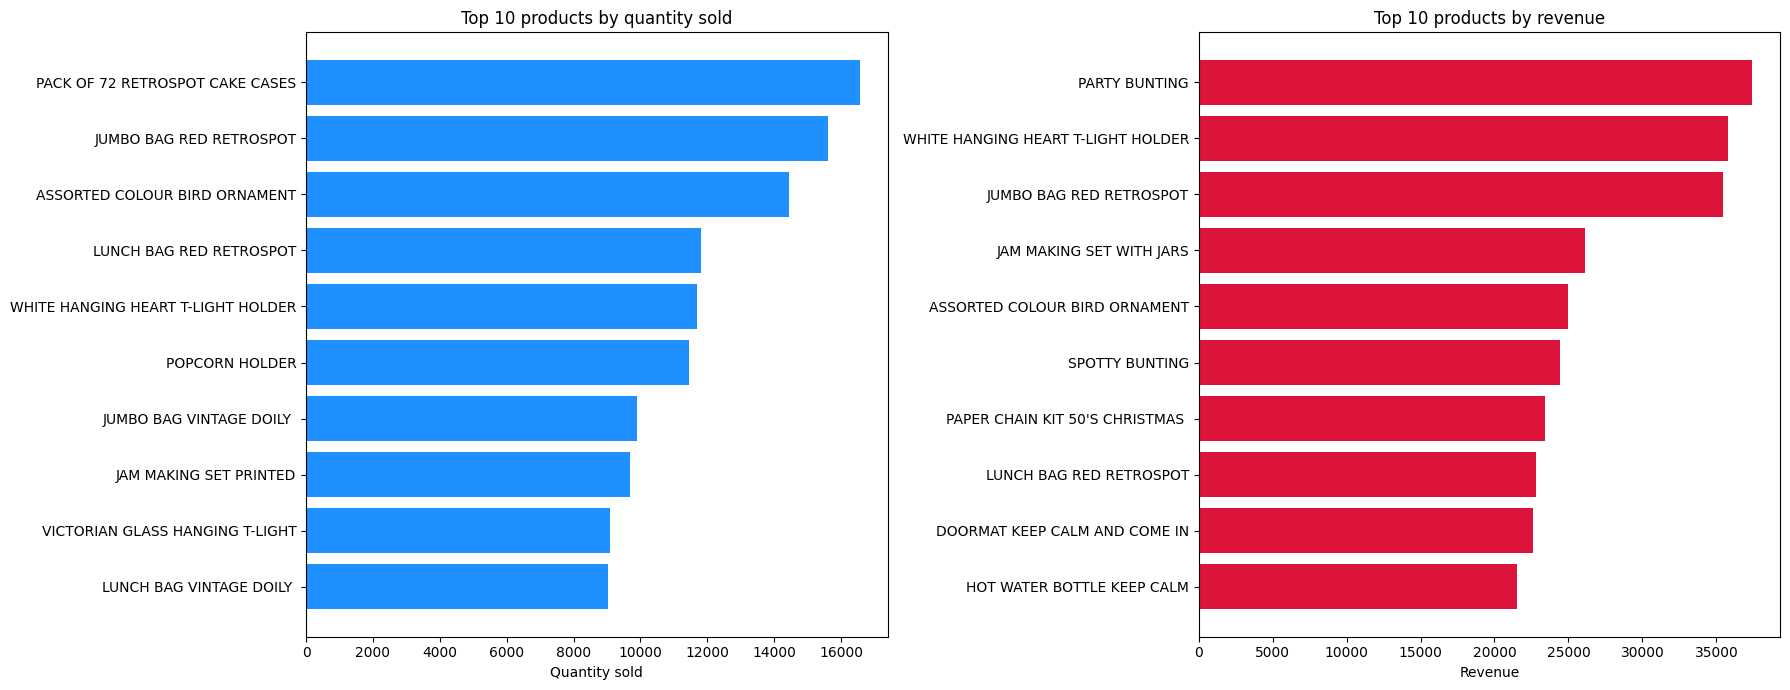

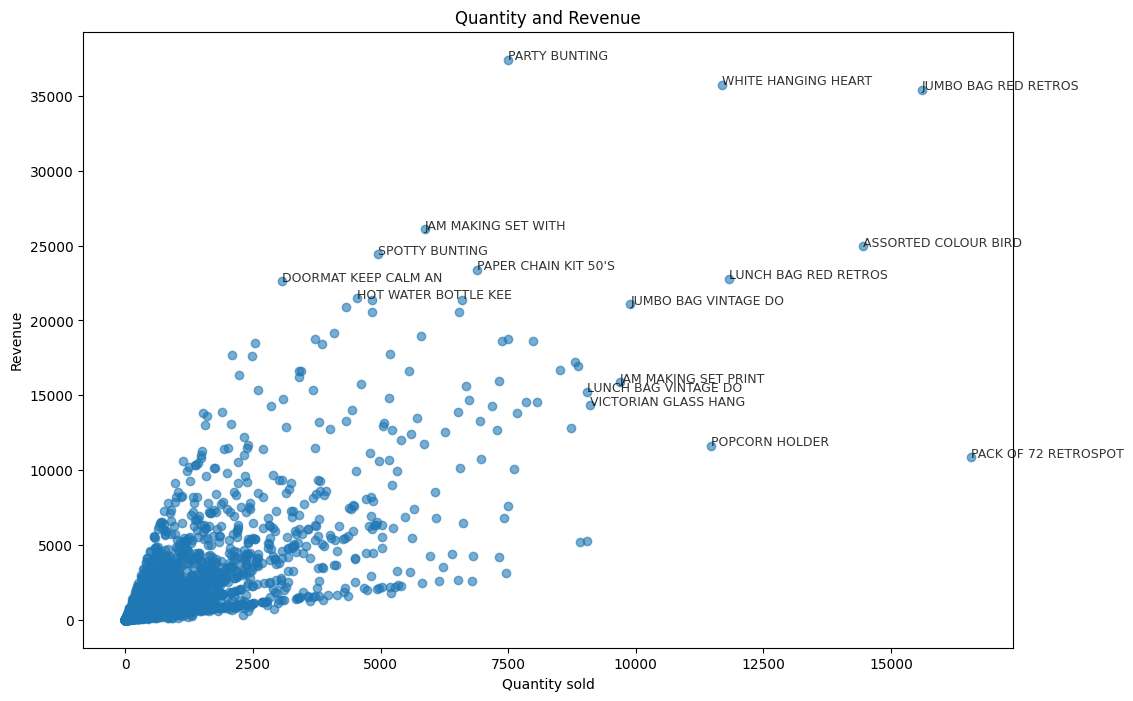

In [ ]:
products = (
    products_only.groupby("StockCode")
    .agg(
        Description = ("Description", lambda x: x.mode()[0]),
        Quantity = ("Quantity", "sum"),
        Revenue = ("Revenue", "sum"),
        Orders = ("Invoice", "nunique")
    )
)

top_quantity = products.sort_values("Quantity", ascending = False).head(10)
top_revenue = products.sort_values("Revenue", ascending = False).head(10)

fig, axes = plt.subplots(1, 2, figsize = (18, 7))

axes[0].barh(
    top_quantity["Description"],
    top_quantity["Quantity"],
    color = "dodgerblue")

axes[0].set_title("Top 10 products by quantity sold")
axes[0].set_xlabel("Quantity sold")
axes[0].invert_yaxis()

axes[1].barh(
    top_revenue["Description"],
    top_revenue["Revenue"],
    color = "crimson")

axes[1].set_title("Top 10 products by revenue")
axes[1].set_xlabel("Revenue")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

plt.figure(figsize = (12, 8))

plt.scatter(
    products["Quantity"],
    products["Revenue"],
    alpha = 0.6)

top_products = pd.concat([top_quantity, top_revenue]).drop_duplicates()

for _, row in top_products.iterrows():
    plt.annotate(
        row["Description"][:20],
        (row["Quantity"], row["Revenue"]),
        fontsize = 9,
        alpha = 0.8)

plt.xlabel("Quantity sold")
plt.ylabel("Revenue")
plt.title("Quantity and Revenue")

plt.show()

Выводы:

По количеству проданных единиц наиболее популярным товаром оказался PACK OF 72 RETROSPOT CAKE CASES. Также в число самых часто покупаемых товаров вошли JUMBO BAG RED RETROSPOT, ASSORTED COLOUR BIRD ORNAMENT, LUNCH BAG RED RETROSPOT и WHITE HANGING HEART T-LIGHT HOLDER.

При этом рейтинг по выручке отличается от рейтинга по количеству продаж. Наибольшую выручку приносит товар PARTY BUNTING, хотя по количеству проданных единиц он не входит в топ-10. Это означает, что данный товар имеет более высокую цену и приносит большую выручку с каждой продажи.

Товар WHITE HANGING HEART T-LIGHT HOLDER присутствует в обоих рейтингах и занимает высокие позиции как по количеству продаж, так и по выручке. Следовательно, он является одним из наиболее успешных товаров магазина: его покупают часто, и он одновременно приносит значительную выручку.

JUMBO BAG RED RETROSPOT и ASSORTED COLOUR BIRD ORNAMENT также входят в оба списка, что указывает на их устойчивую популярность и коммерческую ценность.
С другой стороны, некоторые товары попали только в рейтинг по количеству продаж, но отсутствуют среди лидеров по выручке. Например, PACK OF 72 RETROSPOT CAKE CASES и POPCORN HOLDER продаются в больших объёмах, однако не дают максимальной выручки. Вероятно, это связано с их низкой ценой.

In [ ]:
code_to_name = products["Description"].to_dict()

invoice_products = (
    products_only.groupby("Invoice")["StockCode"]
    .apply(lambda x: sorted(set(x))))

pair_counter = Counter()

for product_codes in invoice_products:
    if len(product_codes) >= 2:
        pair_counter.update(combinations(product_codes, 2))

top_pairs = pd.DataFrame(
    pair_counter.most_common(20),
    columns = ["Pair", "Count"])

top_pairs["StockCode 1"] = top_pairs["Pair"].apply(lambda x: x[0])
top_pairs["StockCode 2"] = top_pairs["Pair"].apply(lambda x: x[1])

top_pairs["Product 1"] = top_pairs["StockCode 1"].map(code_to_name)
top_pairs["Product 2"] = top_pairs["StockCode 2"].map(code_to_name)

top_pairs = top_pairs[["StockCode 1", "Product 1", "StockCode 2", "Product 2", "Count"]]
print(top_pairs.to_string(index = False))


StockCode 1                          Product 1 StockCode 2                         Product 2  Count
      22386            JUMBO BAG PINK POLKADOT      85099B           JUMBO BAG RED RETROSPOT    751
      22697    GREEN REGENCY TEACUP AND SAUCER       22699  ROSES REGENCY TEACUP AND SAUCER     743
      21931             JUMBO STORAGE BAG SUKI      85099B           JUMBO BAG RED RETROSPOT    669
      22411  JUMBO SHOPPER VINTAGE RED PAISLEY      85099B           JUMBO BAG RED RETROSPOT    633
      22726         ALARM CLOCK BAKELIKE GREEN       22727         ALARM CLOCK BAKELIKE RED     624
      20725            LUNCH BAG RED RETROSPOT       22383            LUNCH BAG SUKI DESIGN     622
      22697    GREEN REGENCY TEACUP AND SAUCER       22698    PINK REGENCY TEACUP AND SAUCER    614
      20725            LUNCH BAG RED RETROSPOT       20727           LUNCH BAG  BLACK SKULL.    610
      22698     PINK REGENCY TEACUP AND SAUCER       22699  ROSES REGENCY TEACUP AND SAUCER     577


Анализ наиболее частых товарных пар показал, что покупатели часто приобретают вместе товары одной серии, одного типа или схожего дизайна. Особенно заметны пары среди сумок, чайных наборов и декоративных товаров. Это говорит о наличии выраженного эффекта совместной покупки внутри товарных коллекций.

In [ ]:
num_countries = products_only["Country"].nunique()

print(f"Number of different countries: {num_countries}")

top_10_countries = (
    products_only
    .groupby("Country", as_index = False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending = False)
    .head(10))

top_10_countries["Revenue"] = top_10_countries["Revenue"].round(2)
top_10_countries.index = range(1, 11)
print(top_10_countries)


Number of different countries: 38
           Country     Revenue
1   United Kingdom  5058933.83
2          Germany   154037.38
3           France   135268.52
4             EIRE   133930.70
5      Switzerland    35471.48
6            Spain    33904.39
7          Belgium    30706.48
8         Portugal    23829.01
9      Netherlands    22396.95
10          Norway    21723.36


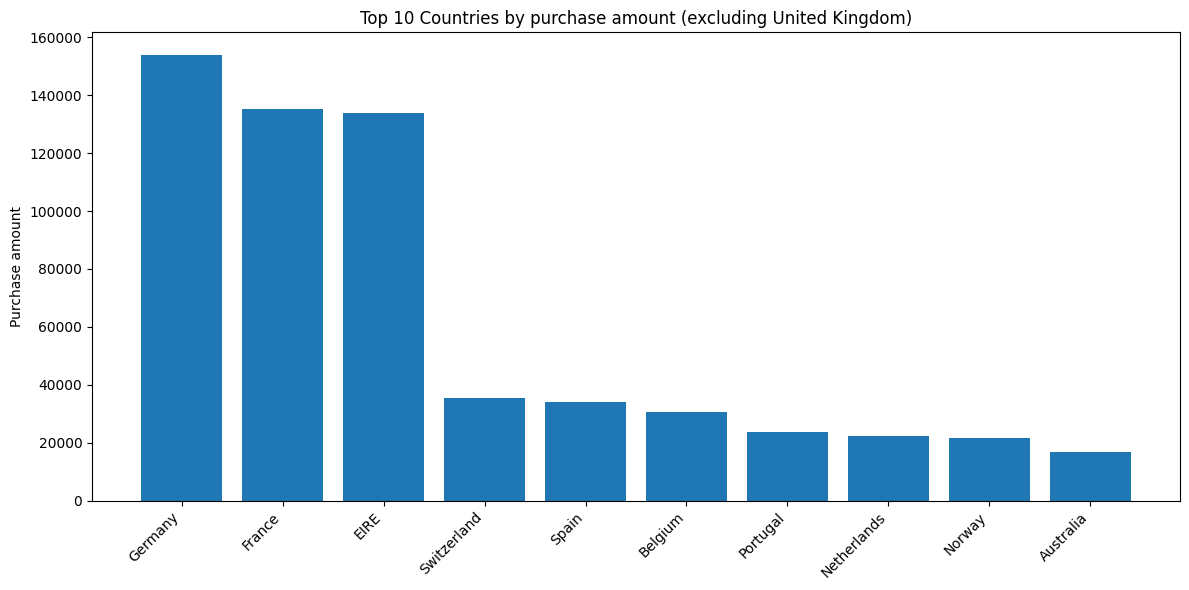

In [ ]:
top_without_uk = (
    products_only[products_only["Country"] != "United Kingdom"]
    .groupby("Country", as_index = False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending = False)
    .head(10))

plt.figure(figsize = (12, 6))

plt.bar(top_without_uk["Country"], top_without_uk["Revenue"])

plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Purchase amount")
plt.title("Top 10 Countries by purchase amount (excluding United Kingdom)")
plt.tight_layout()
plt.show()

Самая прибыльная страна - Великобритания, удалим ее из графика для сохранения нормального масштаба. После Великобритании основная международная выручка приходит всего из трех стран: Германии, Франции и Ирландии. Они сильно опережают остальные рынки.


The top 20% of customers generate 63.9% of revenue


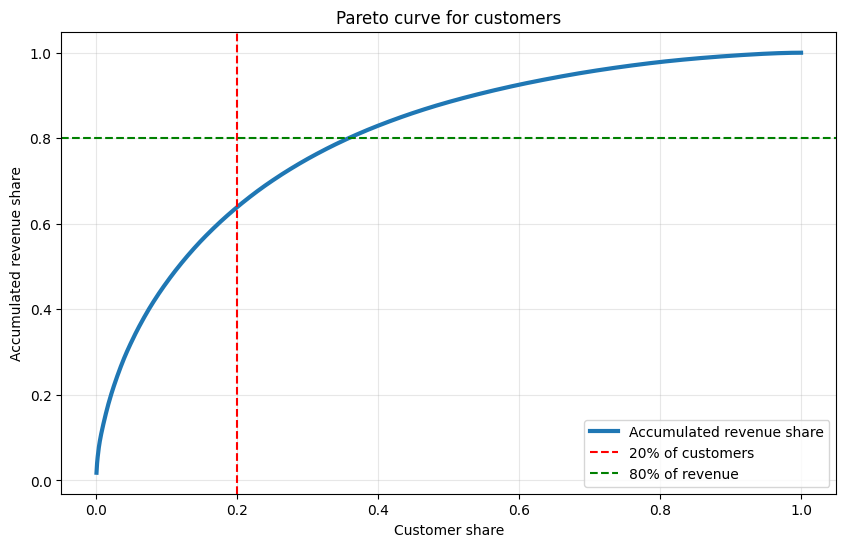

In [ ]:
pareto_df = customer_features_first[["Customer ID", "Monetary"]].copy()

pareto_df = (
    pareto_df
    .groupby("Customer ID", as_index = False)["Monetary"]
    .sum())

pareto_df = pareto_df.sort_values("Monetary", ascending = False).reset_index(drop = True)

pareto_df["cum_revenue"] = pareto_df["Monetary"].cumsum()
pareto_df["cum_revenue_share"] = (pareto_df["cum_revenue"] / pareto_df["Monetary"].sum())

pareto_df["customer_share"] = (np.arange(1, len(pareto_df) + 1) / len(pareto_df))

cutoff = int(len(pareto_df) * 0.2)
revenue_top20 = pareto_df.iloc[:cutoff]["Monetary"].sum()
revenue_share_top20 = revenue_top20 / pareto_df["Monetary"].sum()

print(f"The top 20% of customers generate {revenue_share_top20:.1%} of revenue")

plt.figure(figsize = (10, 6))

plt.plot(
    pareto_df["customer_share"],
    pareto_df["cum_revenue_share"],
    linewidth = 3,
    label = "Accumulated revenue share")

plt.axvline(0.2, color = "red", linestyle = "--", label = "20% of customers")
plt.axhline(0.8, color = "green", linestyle = "--", label = "80% of revenue")

plt.xlabel("Customer share")
plt.ylabel("Accumulated revenue share")
plt.title("Pareto curve for customers")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


Выводы:
Первые 20% клиентов дают 63.9% выручки. Значит, у магазина нет очень узкой группы “супер-клиентов”, от которых всё зависит. Основную выручку формируют не только VIP, но и довольно большая группа Loyal:

верхние 20% клиентов - самые ценные;

следующие 15–20% - тоже очень важны;

нижние 60% клиентов дают сравнительно мало.
